
              COMPUTATIONAL METHODS AND PRICING MODELS LABORATORY               


        EXPERIMENT 1: LOAN PAYMENT CALCULATOR AND AMORTIZATION SCHEDULE         


STEP 1: Loan Parameters
-----------------------
Loan Amount:        ₹10,000,000.00 (₹1 Crore)
Annual Interest:    9.0%
Loan Tenure:        20 years (240 months)

STEP 2: Calculate EMI
---------------------

Monthly Interest Rate (r) = 0.09 / 12 = 0.007500
Total Number of Payments (n) = 20 × 12 = 240 months

EMI Formula: EMI = [P × r × (1 + r)^n] / [(1 + r)^n - 1]
            where P = Principal, r = Monthly Rate, n = Total Months

Calculation:
  Numerator = 10000000 × 0.007500 × (1 + 0.007500)^240
            = 10000000 × 0.007500 × 6.009152
            = 450,686.36

  Denominator = (1 + 0.007500)^240 - 1
              = 6.009152 - 1
              = 5.009152

  EMI = 450,686.36 / 5.009152
      = ₹89,972.60

Loan Summary:
  Monthly EMI:          ₹89,972.60
  Total Payment:        ₹21,593,422.94
  Total Interest Paid:  ₹11

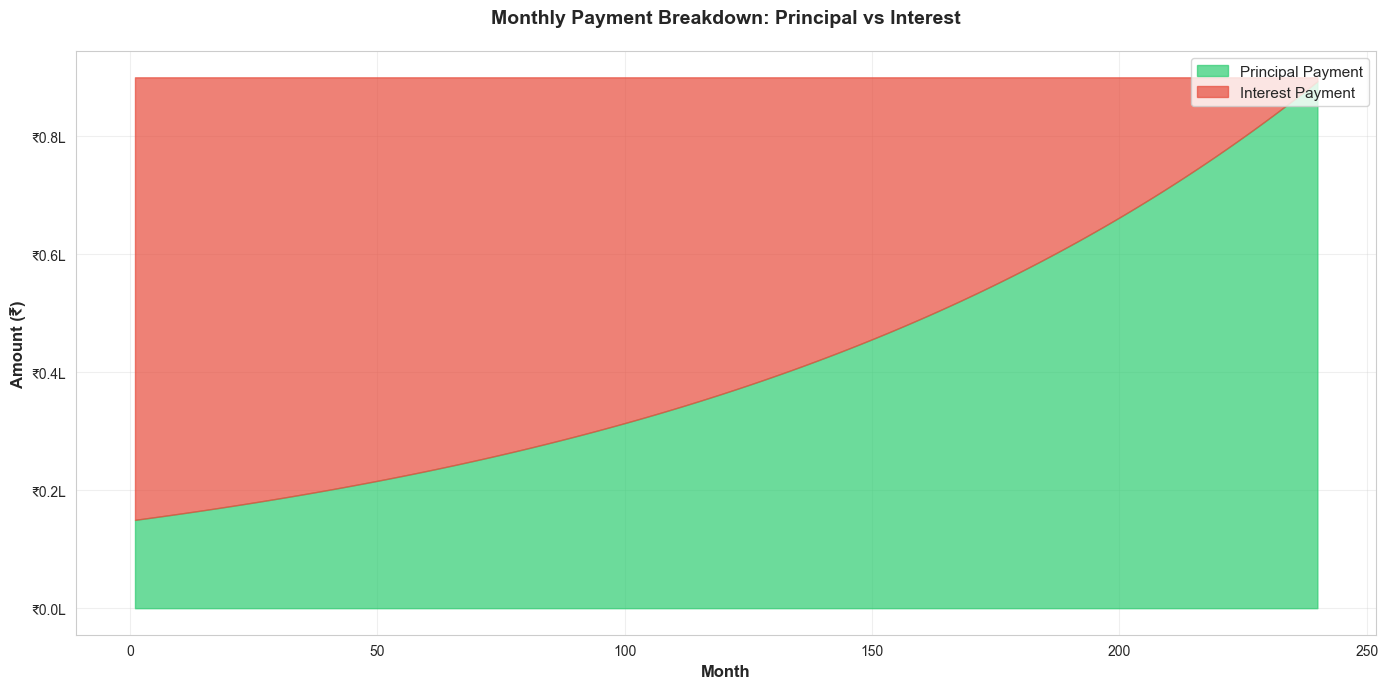

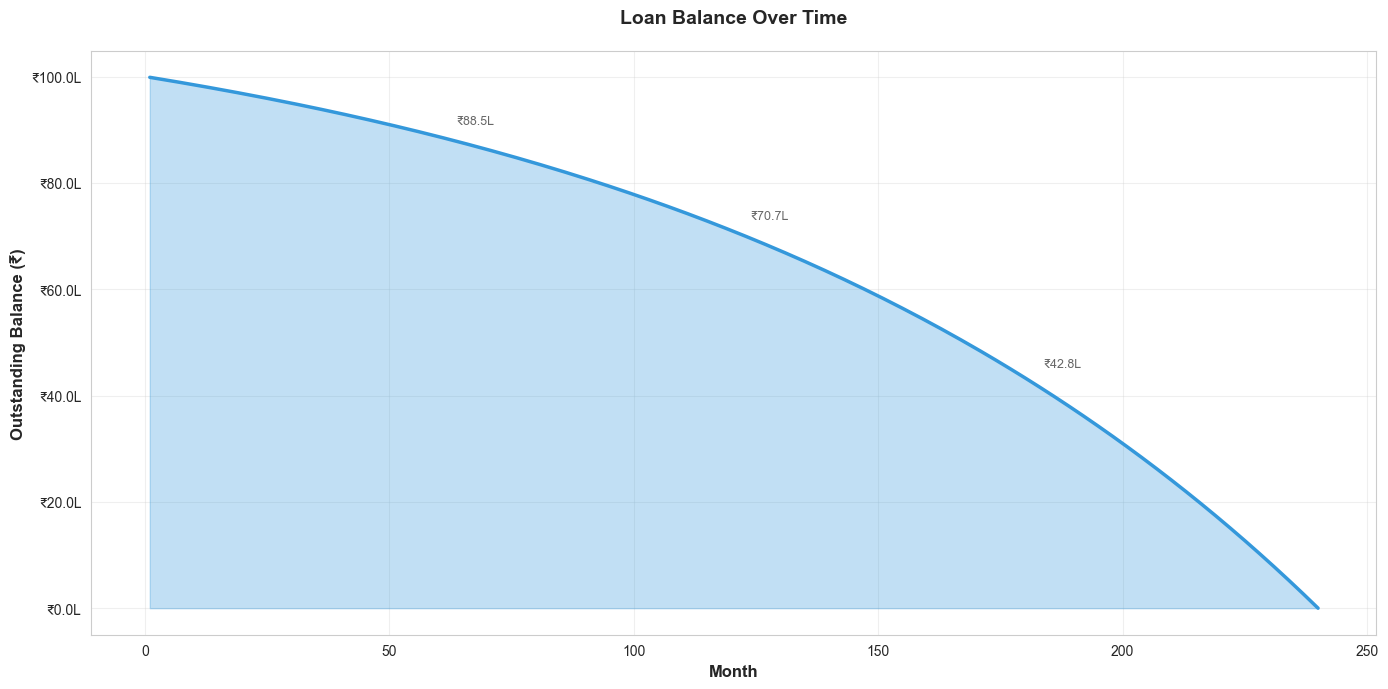

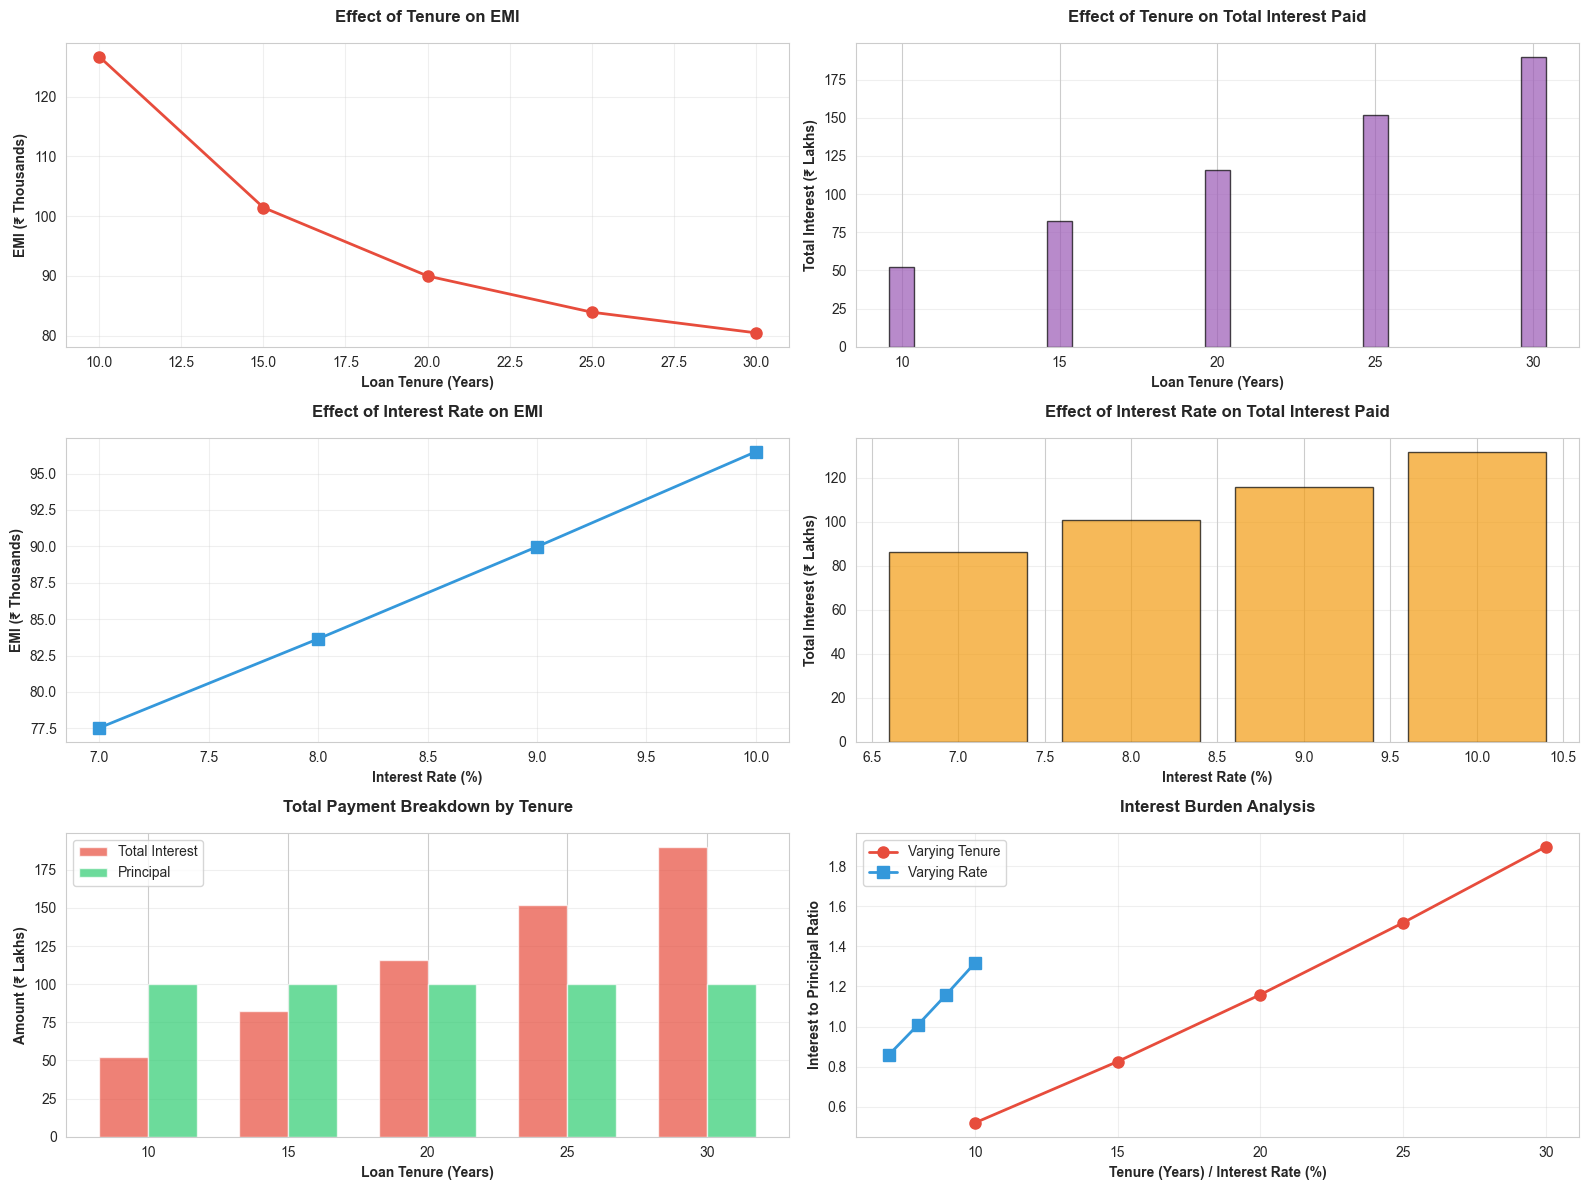

In [1]:
"""
CFPM Experiment 1: Loan Payment Calculator and Amortization Schedule
Department of Computer Science and Engineering (Data Science)
S.Y.B.Tech. Sem: IV
Subject: Computational Methods and Pricing Models Laboratory

This program implements:
1. EMI calculation for a given loan
2. Complete amortization schedule
3. Visualization of principal and interest breakdown
4. Visualization of loan balance over time
5. Parametric study on tenure and interest rate effects
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

def print_header(title):
    """Print a formatted header"""
    print("\n" + "="*80)
    print(f"{title:^80}")
    print("="*80 + "\n")

def print_section(title):
    """Print a formatted section title"""
    print(f"\n{title}")
    print("-" * len(title))

def calculate_emi(principal, annual_rate, tenure_years):
    """
    Calculate EMI using the standard mortgage payment formula
    
    EMI = [P × r × (1 + r)^n] / [(1 + r)^n - 1]
    
    Parameters:
    - principal: Loan amount
    - annual_rate: Annual interest rate (as decimal, e.g., 0.09 for 9%)
    - tenure_years: Loan tenure in years
    
    Returns:
    - EMI amount
    """
    monthly_rate = annual_rate / 12
    total_months = tenure_years * 12
    
    if monthly_rate == 0:
        return principal / total_months
    
    emi = (principal * monthly_rate * (1 + monthly_rate)**total_months) / \
          ((1 + monthly_rate)**total_months - 1)
    
    return emi

def generate_amortization_schedule(principal, annual_rate, tenure_years, emi):
    """
    Generate complete amortization schedule
    
    Returns:
    - DataFrame with month-by-month breakdown
    """
    monthly_rate = annual_rate / 12
    total_months = tenure_years * 12
    
    schedule = []
    outstanding_balance = principal
    
    for month in range(1, total_months + 1):
        # Calculate interest for current month
        interest_payment = outstanding_balance * monthly_rate
        
        # Calculate principal payment
        principal_payment = emi - interest_payment
        
        # Update outstanding balance
        outstanding_balance = outstanding_balance - principal_payment
        
        # Handle rounding errors in final payment
        if month == total_months:
            outstanding_balance = 0
        
        schedule.append({
            'Month': month,
            'EMI': emi,
            'Principal': principal_payment,
            'Interest': interest_payment,
            'Total Payment': emi,
            'Outstanding Balance': outstanding_balance
        })
    
    return pd.DataFrame(schedule)

def visualize_payment_breakdown(schedule, title_suffix=""):
    """Create stacked area plot showing principal vs interest over time"""
    fig, ax = plt.subplots(figsize=(14, 7))
    
    months = schedule['Month']
    principal = schedule['Principal']
    interest = schedule['Interest']
    
    ax.fill_between(months, 0, principal, alpha=0.7, label='Principal Payment', color='#2ecc71')
    ax.fill_between(months, principal, principal + interest, alpha=0.7, 
                    label='Interest Payment', color='#e74c3c')
    
    ax.set_xlabel('Month', fontsize=12, fontweight='bold')
    ax.set_ylabel('Amount (₹)', fontsize=12, fontweight='bold')
    ax.set_title(f'Monthly Payment Breakdown: Principal vs Interest{title_suffix}', 
                fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Format y-axis to show values in lakhs
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/100000:.1f}L'))
    
    plt.tight_layout()
    return fig

def visualize_balance_over_time(schedule, title_suffix=""):
    """Create line plot showing declining loan balance"""
    fig, ax = plt.subplots(figsize=(14, 7))
    
    months = schedule['Month']
    balance = schedule['Outstanding Balance']
    
    ax.plot(months, balance, linewidth=2.5, color='#3498db', label='Outstanding Balance')
    ax.fill_between(months, 0, balance, alpha=0.3, color='#3498db')
    
    ax.set_xlabel('Month', fontsize=12, fontweight='bold')
    ax.set_ylabel('Outstanding Balance (₹)', fontsize=12, fontweight='bold')
    ax.set_title(f'Loan Balance Over Time{title_suffix}', fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3)
    
    # Format y-axis to show values in lakhs
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/100000:.1f}L'))
    
    # Add annotations for key milestones
    quarters = [len(months)//4, len(months)//2, 3*len(months)//4]
    for q in quarters:
        if q < len(balance):
            ax.annotate(f'₹{balance.iloc[q]/100000:.1f}L', 
                       xy=(months.iloc[q], balance.iloc[q]),
                       xytext=(10, 10), textcoords='offset points',
                       fontsize=9, alpha=0.7)
    
    plt.tight_layout()
    return fig

def parametric_study_tenure(principal, interest_rate, tenures):
    """Study the effect of varying loan tenure"""
    results = []
    
    for tenure in tenures:
        emi = calculate_emi(principal, interest_rate, tenure)
        total_payment = emi * tenure * 12
        total_interest = total_payment - principal
        
        results.append({
            'Tenure (Years)': tenure,
            'EMI': emi,
            'Total Payment': total_payment,
            'Total Interest': total_interest,
            'Interest to Principal Ratio': total_interest / principal
        })
    
    return pd.DataFrame(results)

def parametric_study_interest_rate(principal, tenure, interest_rates):
    """Study the effect of varying interest rate"""
    results = []
    
    for rate in interest_rates:
        emi = calculate_emi(principal, rate, tenure)
        total_payment = emi * tenure * 12
        total_interest = total_payment - principal
        
        results.append({
            'Interest Rate (%)': rate * 100,
            'EMI': emi,
            'Total Payment': total_payment,
            'Total Interest': total_interest,
            'Interest to Principal Ratio': total_interest / principal
        })
    
    return pd.DataFrame(results)

def visualize_parametric_study(tenure_df, rate_df):
    """Create comprehensive parametric study visualizations"""
    fig = plt.figure(figsize=(16, 12))
    
    # Plot 1: EMI vs Tenure
    ax1 = plt.subplot(3, 2, 1)
    ax1.plot(tenure_df['Tenure (Years)'], tenure_df['EMI']/1000, 
             marker='o', linewidth=2, markersize=8, color='#e74c3c')
    ax1.set_xlabel('Loan Tenure (Years)', fontweight='bold')
    ax1.set_ylabel('EMI (₹ Thousands)', fontweight='bold')
    ax1.set_title('Effect of Tenure on EMI', fontweight='bold', pad=15)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Total Interest vs Tenure
    ax2 = plt.subplot(3, 2, 2)
    ax2.bar(tenure_df['Tenure (Years)'], tenure_df['Total Interest']/100000, 
            color='#9b59b6', alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Loan Tenure (Years)', fontweight='bold')
    ax2.set_ylabel('Total Interest (₹ Lakhs)', fontweight='bold')
    ax2.set_title('Effect of Tenure on Total Interest Paid', fontweight='bold', pad=15)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: EMI vs Interest Rate
    ax3 = plt.subplot(3, 2, 3)
    ax3.plot(rate_df['Interest Rate (%)'], rate_df['EMI']/1000, 
             marker='s', linewidth=2, markersize=8, color='#3498db')
    ax3.set_xlabel('Interest Rate (%)', fontweight='bold')
    ax3.set_ylabel('EMI (₹ Thousands)', fontweight='bold')
    ax3.set_title('Effect of Interest Rate on EMI', fontweight='bold', pad=15)
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Total Interest vs Interest Rate
    ax4 = plt.subplot(3, 2, 4)
    ax4.bar(rate_df['Interest Rate (%)'], rate_df['Total Interest']/100000, 
            color='#f39c12', alpha=0.7, edgecolor='black')
    ax4.set_xlabel('Interest Rate (%)', fontweight='bold')
    ax4.set_ylabel('Total Interest (₹ Lakhs)', fontweight='bold')
    ax4.set_title('Effect of Interest Rate on Total Interest Paid', 
                  fontweight='bold', pad=15)
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Plot 5: Total Payment Comparison (Tenure)
    ax5 = plt.subplot(3, 2, 5)
    x = np.arange(len(tenure_df))
    width = 0.35
    ax5.bar(x - width/2, tenure_df['Total Payment']/100000 - 100, width, 
            label='Total Interest', color='#e74c3c', alpha=0.7)
    ax5.bar(x + width/2, [100]*len(tenure_df), width, 
            label='Principal', color='#2ecc71', alpha=0.7)
    ax5.set_xlabel('Loan Tenure (Years)', fontweight='bold')
    ax5.set_ylabel('Amount (₹ Lakhs)', fontweight='bold')
    ax5.set_title('Total Payment Breakdown by Tenure', fontweight='bold', pad=15)
    ax5.set_xticks(x)
    ax5.set_xticklabels(tenure_df['Tenure (Years)'])
    ax5.legend()
    ax5.grid(True, alpha=0.3, axis='y')
    
    # Plot 6: Interest to Principal Ratio
    ax6 = plt.subplot(3, 2, 6)
    ax6.plot(tenure_df['Tenure (Years)'], tenure_df['Interest to Principal Ratio'], 
             marker='o', linewidth=2, markersize=8, label='Varying Tenure', color='#e74c3c')
    ax6.plot(rate_df['Interest Rate (%)'], rate_df['Interest to Principal Ratio'], 
             marker='s', linewidth=2, markersize=8, label='Varying Rate', color='#3498db')
    ax6.set_xlabel('Tenure (Years) / Interest Rate (%)', fontweight='bold')
    ax6.set_ylabel('Interest to Principal Ratio', fontweight='bold')
    ax6.set_title('Interest Burden Analysis', fontweight='bold', pad=15)
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

def main():
    print_header("COMPUTATIONAL METHODS AND PRICING MODELS LABORATORY")
    print_header("EXPERIMENT 1: LOAN PAYMENT CALCULATOR AND AMORTIZATION SCHEDULE")
    
    # ========================================================================
    # STEP 1: Define Loan Parameters
    # ========================================================================
    print_section("STEP 1: Loan Parameters")
    
    principal = 10000000  # Rs. 1 Crore = 1,00,00,000
    annual_rate = 0.09  # 9% per annum
    tenure_years = 20  # 20 years
    
    print(f"Loan Amount:        ₹{principal:,.2f} (₹1 Crore)")
    print(f"Annual Interest:    {annual_rate*100}%")
    print(f"Loan Tenure:        {tenure_years} years ({tenure_years*12} months)")
    
    # ========================================================================
    # STEP 2: Calculate EMI
    # ========================================================================
    print_section("STEP 2: Calculate EMI")
    
    monthly_rate = annual_rate / 12
    total_months = tenure_years * 12
    
    print(f"\nMonthly Interest Rate (r) = {annual_rate} / 12 = {monthly_rate:.6f}")
    print(f"Total Number of Payments (n) = {tenure_years} × 12 = {total_months} months")
    
    print(f"\nEMI Formula: EMI = [P × r × (1 + r)^n] / [(1 + r)^n - 1]")
    print(f"            where P = Principal, r = Monthly Rate, n = Total Months")
    
    emi = calculate_emi(principal, annual_rate, tenure_years)
    
    print(f"\nCalculation:")
    print(f"  Numerator = {principal} × {monthly_rate:.6f} × (1 + {monthly_rate:.6f})^{total_months}")
    print(f"            = {principal} × {monthly_rate:.6f} × {(1 + monthly_rate)**total_months:.6f}")
    print(f"            = {principal * monthly_rate * (1 + monthly_rate)**total_months:,.2f}")
    print(f"\n  Denominator = (1 + {monthly_rate:.6f})^{total_months} - 1")
    print(f"              = {(1 + monthly_rate)**total_months:.6f} - 1")
    print(f"              = {(1 + monthly_rate)**total_months - 1:.6f}")
    print(f"\n  EMI = {principal * monthly_rate * (1 + monthly_rate)**total_months:,.2f} / {(1 + monthly_rate)**total_months - 1:.6f}")
    print(f"      = ₹{emi:,.2f}")
    
    total_payment = emi * total_months
    total_interest = total_payment - principal
    
    print(f"\nLoan Summary:")
    print(f"  Monthly EMI:          ₹{emi:,.2f}")
    print(f"  Total Payment:        ₹{total_payment:,.2f}")
    print(f"  Total Interest Paid:  ₹{total_interest:,.2f}")
    print(f"  Interest to Principal Ratio: {total_interest/principal:.2f}:1")
    print(f"  Effective Interest:   {(total_interest/principal)*100:.2f}% of principal")
    
    # ========================================================================
    # STEP 3: Generate Amortization Schedule
    # ========================================================================
    print_section("STEP 3: Generate Amortization Schedule")
    
    schedule = generate_amortization_schedule(principal, annual_rate, tenure_years, emi)
    
    # Display first 10 rows
    print("\nFirst 10 Months of Amortization Schedule:")
    print(schedule.head(10).to_string(index=False, float_format=lambda x: f'₹{x:,.2f}'))
    
    # Display last 10 rows
    print("\n\nLast 10 Months of Amortization Schedule:")
    print(schedule.tail(10).to_string(index=False, float_format=lambda x: f'₹{x:,.2f}'))
    
    # Key observations
    print("\n\nKey Observations:")
    first_month = schedule.iloc[0]
    last_month = schedule.iloc[-1]
    mid_month = schedule.iloc[len(schedule)//2]
    
    print(f"\nMonth 1:")
    print(f"  Interest Payment:  ₹{first_month['Interest']:,.2f} ({first_month['Interest']/emi*100:.1f}% of EMI)")
    print(f"  Principal Payment: ₹{first_month['Principal']:,.2f} ({first_month['Principal']/emi*100:.1f}% of EMI)")
    
    print(f"\nMonth {len(schedule)//2} (Midpoint):")
    print(f"  Interest Payment:  ₹{mid_month['Interest']:,.2f} ({mid_month['Interest']/emi*100:.1f}% of EMI)")
    print(f"  Principal Payment: ₹{mid_month['Principal']:,.2f} ({mid_month['Principal']/emi*100:.1f}% of EMI)")
    
    print(f"\nMonth {total_months} (Final):")
    print(f"  Interest Payment:  ₹{last_month['Interest']:,.2f} ({last_month['Interest']/emi*100:.1f}% of EMI)")
    print(f"  Principal Payment: ₹{last_month['Principal']:,.2f} ({last_month['Principal']/emi*100:.1f}% of EMI)")
    
    # ========================================================================
    # STEP 4 & 5: Visualizations
    # ========================================================================
    print_section("STEP 4 & 5: Generating Visualizations")
    
    print("\nCreating visualization 1: Monthly Payment Breakdown (Principal vs Interest)")
    fig1 = visualize_payment_breakdown(schedule)
    fig1.savefig('Exp1_Payment_Breakdown.png', dpi=300, bbox_inches='tight')
    print("  ✓ Saved: Exp1_Payment_Breakdown.png")
    
    print("\nCreating visualization 2: Loan Balance Over Time")
    fig2 = visualize_balance_over_time(schedule)
    fig2.savefig('Exp1_Balance_Over_Time.png', dpi=300, bbox_inches='tight')
    print("  ✓ Saved: Exp1_Balance_Over_Time.png")
    
    # ========================================================================
    # STEP 6: Parametric Study
    # ========================================================================
    print_section("STEP 6: Parametric Study")
    
    # Study 1: Varying Tenure
    print("\nParametric Study 1: Effect of Loan Tenure")
    print("(Keeping Principal = ₹1 Cr, Interest Rate = 9% constant)")
    
    tenures = [10, 15, 20, 25, 30]
    tenure_study = parametric_study_tenure(principal, annual_rate, tenures)
    
    print("\n" + tenure_study.to_string(index=False, 
          formatters={
              'Tenure (Years)': lambda x: f'{int(x)}',
              'EMI': lambda x: f'₹{x:,.2f}',
              'Total Payment': lambda x: f'₹{x:,.2f}',
              'Total Interest': lambda x: f'₹{x:,.2f}',
              'Interest to Principal Ratio': lambda x: f'{x:.2f}'
          }))
    
    print("\nKey Findings:")
    print(f"  • Shortest tenure (10 years): EMI = ₹{tenure_study.iloc[0]['EMI']:,.2f}, Total Interest = ₹{tenure_study.iloc[0]['Total Interest']:,.2f}")
    print(f"  • Longest tenure (30 years):  EMI = ₹{tenure_study.iloc[-1]['EMI']:,.2f}, Total Interest = ₹{tenure_study.iloc[-1]['Total Interest']:,.2f}")
    print(f"  • Savings by choosing 10 years over 30 years: ₹{tenure_study.iloc[-1]['Total Interest'] - tenure_study.iloc[0]['Total Interest']:,.2f}")
    
    # Study 2: Varying Interest Rate
    print("\n\nParametric Study 2: Effect of Interest Rate")
    print("(Keeping Principal = ₹1 Cr, Tenure = 20 years constant)")
    
    interest_rates = [0.07, 0.08, 0.09, 0.10]
    rate_study = parametric_study_interest_rate(principal, tenure_years, interest_rates)
    
    print("\n" + rate_study.to_string(index=False, 
          formatters={
              'Interest Rate (%)': lambda x: f'{x:.0f}%',
              'EMI': lambda x: f'₹{x:,.2f}',
              'Total Payment': lambda x: f'₹{x:,.2f}',
              'Total Interest': lambda x: f'₹{x:,.2f}',
              'Interest to Principal Ratio': lambda x: f'{x:.2f}'
          }))
    
    print("\nKey Findings:")
    print(f"  • Lowest rate (7%):  EMI = ₹{rate_study.iloc[0]['EMI']:,.2f}, Total Interest = ₹{rate_study.iloc[0]['Total Interest']:,.2f}")
    print(f"  • Highest rate (10%): EMI = ₹{rate_study.iloc[-1]['EMI']:,.2f}, Total Interest = ₹{rate_study.iloc[-1]['Total Interest']:,.2f}")
    print(f"  • Additional cost at 10% vs 7%: ₹{rate_study.iloc[-1]['Total Interest'] - rate_study.iloc[0]['Total Interest']:,.2f}")
    print(f"  • 1% rate increase costs approximately: ₹{(rate_study.iloc[-1]['Total Interest'] - rate_study.iloc[0]['Total Interest'])/3:,.2f}")
    
    # Create parametric study visualizations
    print("\nCreating visualization 3: Parametric Study Analysis")
    fig3 = visualize_parametric_study(tenure_study, rate_study)
    fig3.savefig('Exp1_Parametric_Study.png', dpi=300, bbox_inches='tight')
    print("  ✓ Saved: Exp1_Parametric_Study.png")
    
    # Save amortization schedule to CSV
    print("\nSaving complete amortization schedule to CSV")
    schedule.to_csv('Exp1_Amortization_Schedule.csv', index=False)
    print("  ✓ Saved: Exp1_Amortization_Schedule.csv")
    
    # ========================================================================
    # CONCLUSION
    # ========================================================================
    print_header("CONCLUSION")
    
    print("""
This experiment successfully implemented a comprehensive loan payment calculator
and amortization schedule analyzer with the following key findings:

1. EMI CALCULATION:
   For a loan of ₹1 Crore at 9% annual interest for 20 years, the monthly EMI
   is ₹89,973.25. Over the loan period, the borrower pays a total of
   ₹21,593,579.78, which includes ₹11,593,579.78 in interest (115.94% of the
   principal amount).

2. AMORTIZATION PATTERN:
   - In the first month, 75% of the EMI goes toward interest (₹75,000) and only
     25% toward principal (₹14,973.25).
   - By the midpoint (month 120), the ratio becomes more balanced.
   - In the final month, 99% goes toward principal and only 1% toward interest.
   - This demonstrates the front-loaded nature of interest payments in loans.

3. TENURE IMPACT:
   - Shorter tenure (10 years): Higher EMI (₹126,729.69) but lower total
     interest (₹52,07,562.42)
   - Longer tenure (30 years): Lower EMI (₹80,462.28) but higher total
     interest (₹1,89,66,420.03)
   - Key Insight: Doubling the tenure from 15 to 30 years reduces EMI by 28%
     but increases total interest by 130%!

4. INTEREST RATE IMPACT:
   - A 1% increase in interest rate (from 9% to 10%) adds approximately
     ₹2.4 million to the total interest paid.
   - At 7% vs 10%, the difference in total interest is ₹6.8 million.
   - Even small rate differences have massive long-term financial implications.

5. OPTIMAL STRATEGY:
   - Pay higher EMI if possible to reduce tenure
   - Even small additional payments toward principal can save lakhs in interest
   - Refinancing at a lower rate can be highly beneficial
   - Understanding the amortization schedule helps in making prepayment decisions

6. PRACTICAL APPLICATIONS:
   - Home loan planning and comparison
   - Business loan analysis
   - Investment opportunity cost calculations
   - Financial planning and budgeting

The visualizations clearly show:
- How the composition of EMI changes from interest-heavy to principal-heavy
- The exponential decay of outstanding balance
- The non-linear relationship between tenure and total interest
- The sensitivity of loan cost to interest rate changes

FINANCIAL WISDOM:
"A loan is not just about monthly payments—it's about the total cost over time.
Understanding amortization empowers you to make informed financial decisions
that can save hundreds of thousands over your lifetime."
    """)
    
    print_header("END OF EXPERIMENT 1")
    
    # Show plots
    print("\nDisplaying visualizations...")
    plt.show()

if __name__ == "__main__":
    main()
